# RAGAS feature extraction on Merged ASQA/MS MARCO/WikiEval dataset

Notebook này tạo feature table theo từng sample từ `labeled_merged.csv`, chỉ dùng các metric black-box của RAGAS khi **không có ground truth**

Output:
- 3 lần chạy feature extractions với cùng 1 data gốc, 1 prompt và 1 model llm: gpt-4o-mini
- So sánh và phân tích sự sai khác nhau giữa 3 lần chạy, nếu có, để hiểu rõ hơn về sự ổn định của RAGAS khi không có ground truth.

## Imports and setup

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import ast
import importlib
import importlib.util
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import os
sys.path.append('..')

import src.filtering.ragas as _ragas_mod
importlib.reload(_ragas_mod)

from src.filtering.ragas import RAGAS
from src.filtering.ragas_feature_extractor import RagasFeatureExtractor
from src.evaluation import plot_evaluation_results

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
HUGGINGFACE_API_KEY = os.getenv("HUGGINGFACE_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")


pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)
np.random.seed(42)

/opt/homebrew/Caskroom/miniforge/base/envs/rag-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_PATH = Path('../data/labeled_merged.csv')
OUTPUT_DIR = Path('../results/ragas_filter/merged')
N_TIMES = 3

## Imports data and initialize evaluator

In [3]:
df = pd.read_csv(DATA_PATH)
df["label"] = df["label"].astype(int)

expected_columns = {"id", "question", "answer", "context", "label"}
missing_columns = expected_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing columns in CSV: {sorted(missing_columns)}")

print(df.shape)
display(df.head())
print(df["label"].value_counts(dropna=False).sort_index())

(9806, 6)


,id,question,context,answer,label,dataset
0,asqa_0,When does the new bunk'd come out?,"- (List of Bunk'd episodes) The new bunk'd episode 41 comes out on April 21, 2017, episode 42 comes out on April 28,...","The new bunk'd episode 41 comes out on April 21, 2017, episode 42 comes out on April 28, 2017 and episode 42 is due ...",1,asqa
1,asqa_1,Who won the 2016 ncaa football national championship?,- (2016 College Football Playoff National Championship) The 2015 - 2016 season's ncaa national football championship...,The 2015 - 2016 season's ncaa national football championship game was played between the Clemson Tigers and the Alab...,1,asqa
2,asqa_2,When was the last time the death penalty was used in pa?,"- (QA_1) As of 2017, when was the last time the death penalty was carried out in PA? July 6, 1999.\n- (QA_2) As of 2...","The last time the death penalty was used in pa was on July 6, 1999.",1,asqa
3,asqa_3,Where will failure of the left ventricle cause increased pressure?,"- (Heart failure) ""Backward"" failure of the left ventricle causes congestion of the lungs' blood vessels, and theref...","""Backward"" failure of the left ventricle causes congestion of the lungs' blood vessels, and therefore causes increas...",1,asqa
4,asqa_4,Who won the war between ethiopia and italy?,- (Second Italo-Ethiopian War) The first war between Italy and Ethiopia took place from 1895 to 1896. This war was w...,The first war between Italy and Ethiopia took place from 1895 to 1896. This war was won by the Ethiopian army after ...,1,asqa


label
0    4903
1    4903
Name: count, dtype: int64


## RAGAs feature extraction

In [4]:
# Black-box RAGAS metrics: no ground-truth dependent scores
# We intentionally skip answer_correctness / answer_similarity.
metric_names = [
    "faithfulness",
    "answer_relevancy",
    "context_relevancy",
]

evaluator = RAGAS(
    metrics=metric_names,

    # OpenAI models
    llm_model="gpt-4o-mini",
    embedding_model="text-embedding-3-small",

    # optional
    api_key=OPENAI_API_KEY,

    # optional
    temperature=0,
)

for i in range(N_TIMES):
    print(f"\n=== RAGAS feature extraction: Run {i+1}/{N_TIMES} ===")
    feature_path = OUTPUT_DIR / f"merged_ragas_features_{i+1}.csv"
    checkpoint_path = OUTPUT_DIR / f"merged_ragas_checkpoints_{i+1}.csv"
    extractor = RagasFeatureExtractor(ragas_evaluator=evaluator, feature_cols=metric_names)
    feature_df = extractor.transform(data=df, 
                                    feature_path=feature_path,
                                    checkpoint_path=checkpoint_path)
    print(f"> Save RAGAS features to {feature_path}")
    print(feature_df.shape)
    display(feature_df.describe().T)   
    display(feature_df.head())


=== RAGAS feature extraction: Run 1/3 ===
Resuming from sample 9806
> Save RAGAS features to ../results/ragas_filter/merged/merged_ragas_features_1.csv
(9806, 6)


,count,mean,std,min,25%,50%,75%,max
faithfulness,9806.0,0.679226,0.346379,0.0,0.400000,0.800000,1.000000,1.0
answer_relevancy,9806.0,0.719444,0.217579,0.0,0.652082,0.772606,0.861167,1.0
context_relevancy,9806.0,0.331154,0.265501,0.0,0.142857,0.250000,0.428571,1.0
label,9806.0,0.500000,0.500025,0.0,0.000000,0.500000,1.000000,1.0


,id,faithfulness,answer_relevancy,context_relevancy,label,dataset
0,asqa_0,0.666667,0.710722,0.142857,1,asqa
1,asqa_1,1.000000,0.948917,0.166667,1,asqa
2,asqa_2,1.000000,0.965836,0.166667,1,asqa
3,asqa_3,1.000000,0.712995,0.166667,1,asqa
4,asqa_4,1.000000,0.770476,0.200000,1,asqa



=== RAGAS feature extraction: Run 2/3 ===
Resuming from sample 9806
> Save RAGAS features to ../results/ragas_filter/merged/merged_ragas_features_2.csv
(9806, 6)


,count,mean,std,min,25%,50%,75%,max
faithfulness,9805.0,0.679689,0.346097,0.0,0.400000,0.800000,1.000000,1.0
answer_relevancy,9806.0,0.721616,0.214478,0.0,0.654541,0.773243,0.861250,1.0
context_relevancy,9806.0,0.331757,0.265949,0.0,0.142857,0.250000,0.428571,1.0
label,9806.0,0.500000,0.500025,0.0,0.000000,0.500000,1.000000,1.0


,id,faithfulness,answer_relevancy,context_relevancy,label,dataset
0,asqa_0,0.666667,0.726235,0.142857,1,asqa
1,asqa_1,1.000000,0.948926,0.166667,1,asqa
2,asqa_2,1.000000,0.965836,0.166667,1,asqa
3,asqa_3,1.000000,0.655362,0.166667,1,asqa
4,asqa_4,1.000000,0.708895,0.300000,1,asqa



=== RAGAS feature extraction: Run 3/3 ===
Resuming from sample 9806
> Save RAGAS features to ../results/ragas_filter/merged/merged_ragas_features_3.csv
(9806, 6)


,count,mean,std,min,25%,50%,75%,max
faithfulness,9806.0,0.679823,0.346348,0.0,0.400000,0.800000,1.000000,1.0
answer_relevancy,9806.0,0.719997,0.216924,0.0,0.651663,0.771772,0.861019,1.0
context_relevancy,9806.0,0.332640,0.266644,0.0,0.142857,0.250000,0.444444,1.0
label,9806.0,0.500000,0.500025,0.0,0.000000,0.500000,1.000000,1.0


,id,faithfulness,answer_relevancy,context_relevancy,label,dataset
0,asqa_0,0.666667,0.726208,0.142857,1,asqa
1,asqa_1,1.000000,0.948921,0.166667,1,asqa
2,asqa_2,1.000000,0.965836,0.166667,1,asqa
3,asqa_3,1.000000,0.699630,0.166667,1,asqa
4,asqa_4,1.000000,0.708895,0.300000,1,asqa


## RAGAS feature extraction results analysis

Load features and labels


=== Comparison of RAGAS features across 3 runs ===
Run 1:
  faithfulness: mean=0.6792, std=0.3464
  answer_relevancy: mean=0.7194, std=0.2176
  context_relevancy: mean=0.3312, std=0.2655
Run 2:
  faithfulness: mean=0.6797, std=0.3461
  answer_relevancy: mean=0.7216, std=0.2145
  context_relevancy: mean=0.3318, std=0.2659
Run 3:
  faithfulness: mean=0.6798, std=0.3463
  answer_relevancy: mean=0.7200, std=0.2169
  context_relevancy: mean=0.3326, std=0.2666


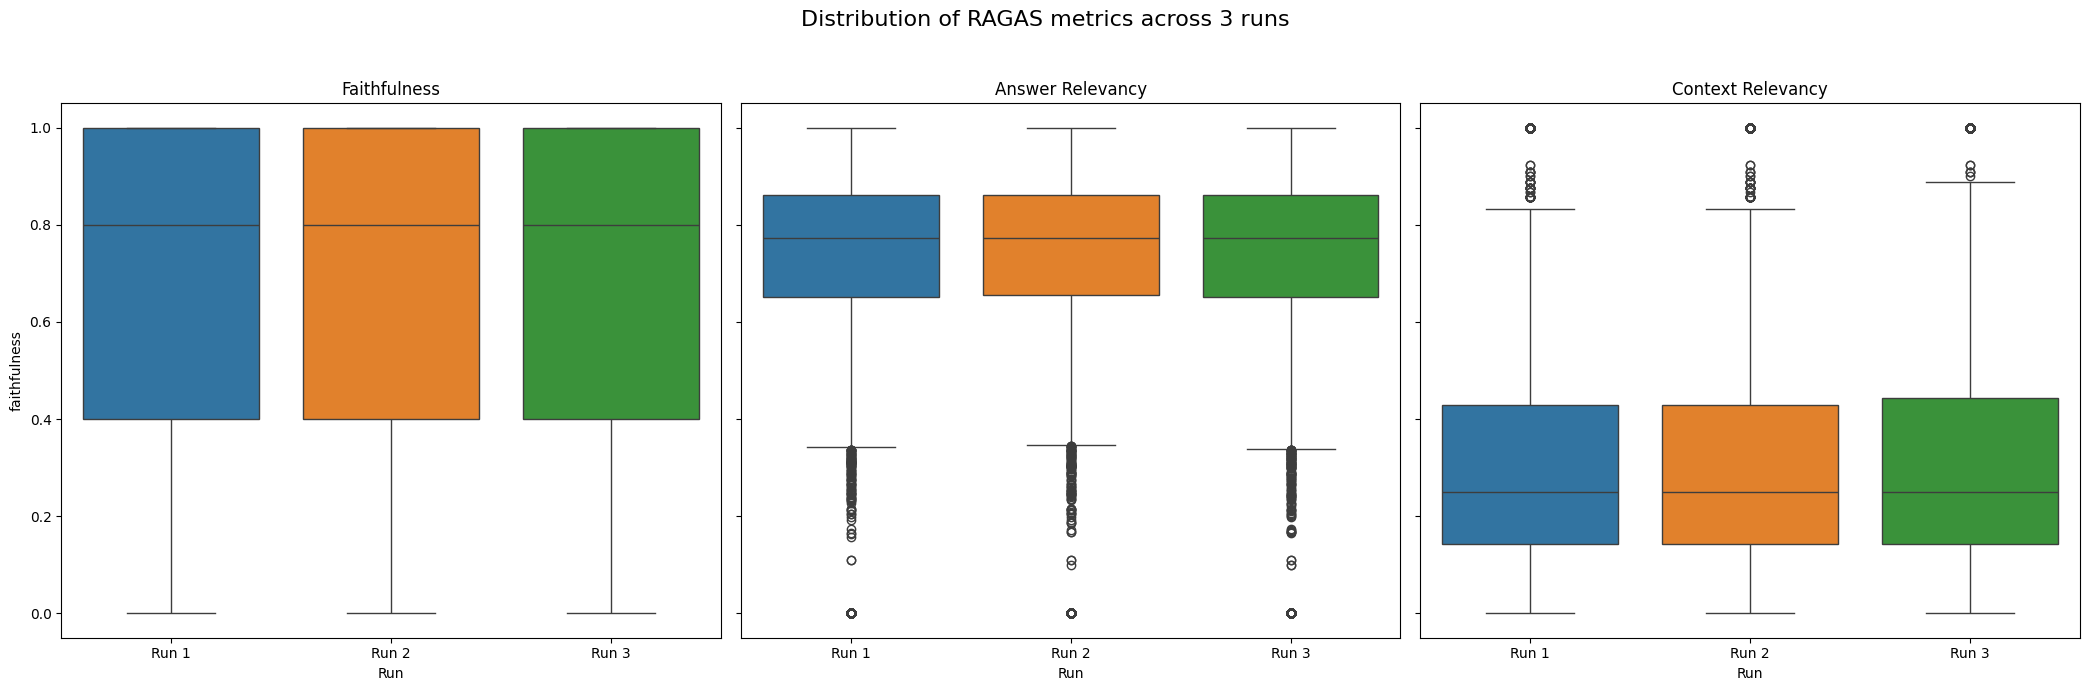

In [6]:
feature_dfs = []
for i in range(N_TIMES):
    feature_path = OUTPUT_DIR / f"merged_ragas_features_{i+1}.csv"
    feature_df = pd.read_csv(feature_path)
    feature_dfs.append(feature_df)
print(f"\n=== Comparison of RAGAS features across {N_TIMES} runs ===")

fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharey=True)

for i, feature_df in enumerate(feature_dfs):
    print(f"Run {i+1}:")
    for metric in metric_names:
        print(f"  {metric}: mean={feature_df[metric].mean():.4f}, std={feature_df[metric].std():.4f}")

for ax, metric in zip(axes, metric_names):
    metric_df = pd.DataFrame({
        f"Run {i+1}": feature_df[metric]
        for i, feature_df in enumerate(feature_dfs)
    })

    sns.boxplot(data=metric_df, ax=ax)

    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("Run")
    ax.set_ylabel(metric if ax is axes[0] else "")

fig.suptitle(f"Distribution of RAGAS metrics across {N_TIMES} runs", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
